# 🚗 Tesla Deliveries & Production — End-to-End ML Pipeline
**Dataset:** [Tesla EA Deliveries and Production Data (2015–2025)](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025)

This notebook implements a complete ML pipeline covering:
1. Data Loading & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Regression Modeling (6 algorithms × 2 targets)
5. Hyperparameter Tuning (GridSearchCV)
6. Time Series Forecasting (12-month ahead)

---

## 0. Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# ── Plot theme ──────────────────────────────────────────────────────────────
TESLA_RED = '#E31937'
DARK_BG   = '#0d0d0d'
CARD_BG   = '#1a1a1a'
ACCENT    = '#5EB8FF'
GOLD      = '#F4C542'
TEXT_LIGHT= '#E8E8E8'
MUTED     = '#888888'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': '#333333', 'axes.labelcolor': TEXT_LIGHT,
    'text.color': TEXT_LIGHT, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': '#2a2a2a', 'grid.linewidth': 0.6,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'axes.labelsize': 10,
})
print('✔ Libraries loaded')

## 1. Load Data

In [ ]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

In [ ]:
print('Data Types:')
print(df.dtypes)
print('\nBasic Statistics:')
df.describe()

## 2. Preprocessing

Steps:
- Parse `Year` + `Month` into a `Date` column
- Check for missing values and duplicates
- Encode categorical columns
- Create 5 derived business-logic features

In [ ]:
# 2a. Date column
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(Day=1))
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# 2b. Quality checks
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')

# 2c. Derived features
df['Delivery_Efficiency']   = (df['Estimated_Deliveries'] / df['Production_Units']).round(4)
df['Revenue_Proxy_M']       = (df['Estimated_Deliveries'] * df['Avg_Price_USD'] / 1e6).round(2)
df['Price_per_kWh']         = (df['Avg_Price_USD'] / df['Battery_Capacity_kWh']).round(2)
df['CO2_per_Delivery']      = (df['CO2_Saved_tons'] / df['Estimated_Deliveries']).round(4)
df['Stations_per_Delivery'] = (df['Charging_Stations'] / df['Estimated_Deliveries']).round(4)
df['YearMonth_Idx']         = (df['Year'] - df['Year'].min()) * 12 + df['Month']

# 2d. Encode categoricals
le_region = LabelEncoder(); le_model = LabelEncoder(); le_source = LabelEncoder()
df['Region_Enc'] = le_region.fit_transform(df['Region'])
df['Model_Enc']  = le_model.fit_transform(df['Model'])
df['Source_Enc'] = le_source.fit_transform(df['Source_Type'])

print('\nRegions :', df['Region'].unique().tolist())
print('Models  :', df['Model'].unique().tolist())
print('\nPreprocessing complete ✔')

## 3. Exploratory Data Analysis

We explore:
- Annual delivery trends by model
- Regional market share
- Average price trajectory
- Delivery efficiency per model
- Feature correlations
- Distributions, seasonality, and CO₂ impact

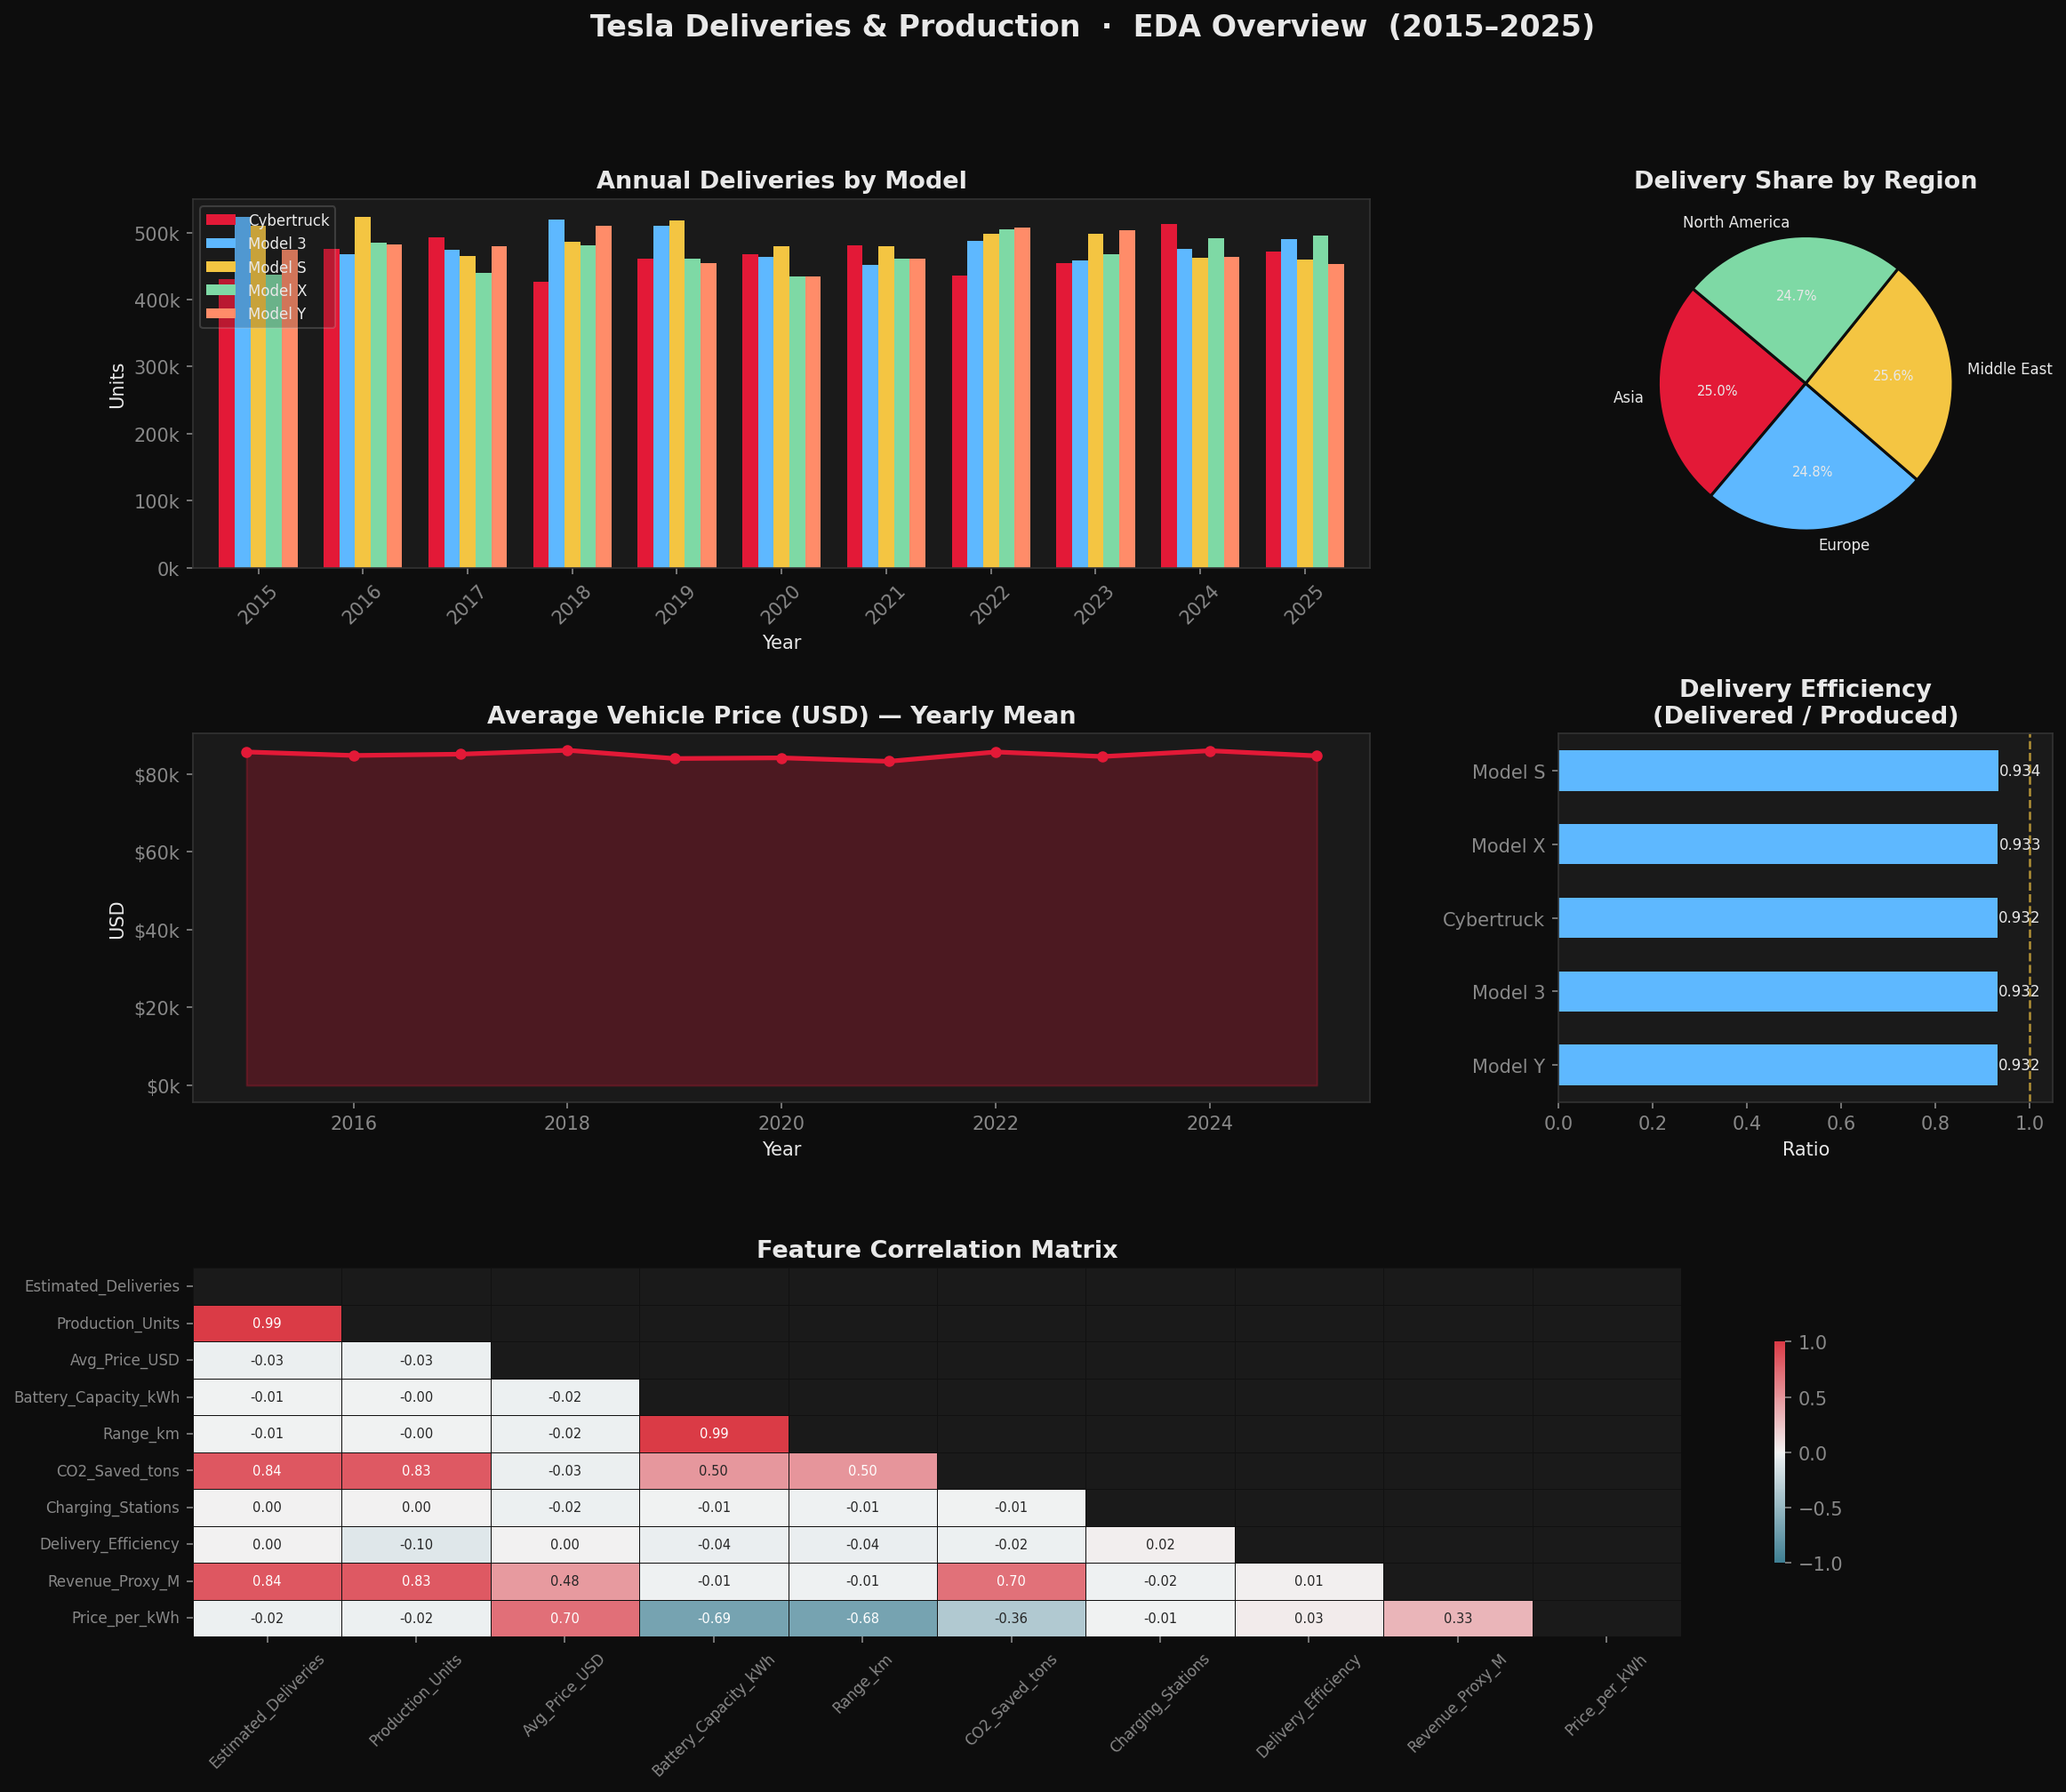

In [ ]:
from matplotlib.ticker import FuncFormatter

fig = plt.figure(figsize=(18, 14), facecolor=DARK_BG)
fig.suptitle('Tesla Deliveries & Production  ·  EDA Overview  (2015–2025)',
             fontsize=16, fontweight='bold', color=TEXT_LIGHT, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# Annual deliveries by model
ax1 = fig.add_subplot(gs[0, :2])
annual = df.groupby(['Year','Model'])['Estimated_Deliveries'].sum().unstack(fill_value=0)
colors = [TESLA_RED, ACCENT, GOLD, '#7ED9A5', '#FF8C69']
annual.plot(kind='bar', ax=ax1, color=colors, width=0.75, edgecolor='none')
ax1.set_title('Annual Deliveries by Model')
ax1.set_xlabel('Year'); ax1.set_ylabel('Units')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax1.legend(loc='upper left', fontsize=8, framealpha=0.2)
ax1.tick_params(axis='x', rotation=45)

# Region share
ax2 = fig.add_subplot(gs[0, 2])
reg_share = df.groupby('Region')['Estimated_Deliveries'].sum()
wedge_colors = [TESLA_RED, ACCENT, GOLD, '#7ED9A5']
wedges, texts, autotexts = ax2.pie(reg_share, labels=reg_share.index, autopct='%1.1f%%',
    colors=wedge_colors, startangle=140,
    textprops={'color': TEXT_LIGHT, 'fontsize': 8},
    wedgeprops={'edgecolor': DARK_BG, 'linewidth': 1.5})
for at in autotexts: at.set_fontsize(7)
ax2.set_title('Delivery Share by Region')

# Avg price trend
ax3 = fig.add_subplot(gs[1, :2])
price_yr = df.groupby('Year')['Avg_Price_USD'].mean()
ax3.fill_between(price_yr.index, price_yr.values, alpha=0.25, color=TESLA_RED)
ax3.plot(price_yr.index, price_yr.values, color=TESLA_RED, lw=2.5, marker='o', ms=5)
ax3.set_title('Average Vehicle Price (USD) — Yearly Mean')
ax3.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))

# Delivery efficiency
ax4 = fig.add_subplot(gs[1, 2])
eff_model = df.groupby('Model')['Delivery_Efficiency'].mean().sort_values()
bars = ax4.barh(eff_model.index, eff_model.values, color=ACCENT, edgecolor='none', height=0.55)
ax4.axvline(1.0, color=GOLD, lw=1.2, ls='--', alpha=0.7)
ax4.set_title('Delivery Efficiency\n(Delivered / Produced)')
for bar, val in zip(bars, eff_model.values):
    ax4.text(val+0.002, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)

# Correlation heatmap
ax5 = fig.add_subplot(gs[2, :])
num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
            'Battery_Capacity_kWh','Range_km','CO2_Saved_tons',
            'Charging_Stations','Delivery_Efficiency','Revenue_Proxy_M','Price_per_kWh']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(220,10,as_cmap=True),
            vmax=1, vmin=-1, center=0, annot=True, fmt='.2f',
            linewidths=0.4, linecolor='#111', annot_kws={'size':7}, ax=ax5,
            cbar_kws={'shrink':0.6})
ax5.set_title('Feature Correlation Matrix')
ax5.tick_params(axis='x', rotation=45, labelsize=8)
ax5.tick_params(axis='y', rotation=0, labelsize=8)
plt.show()

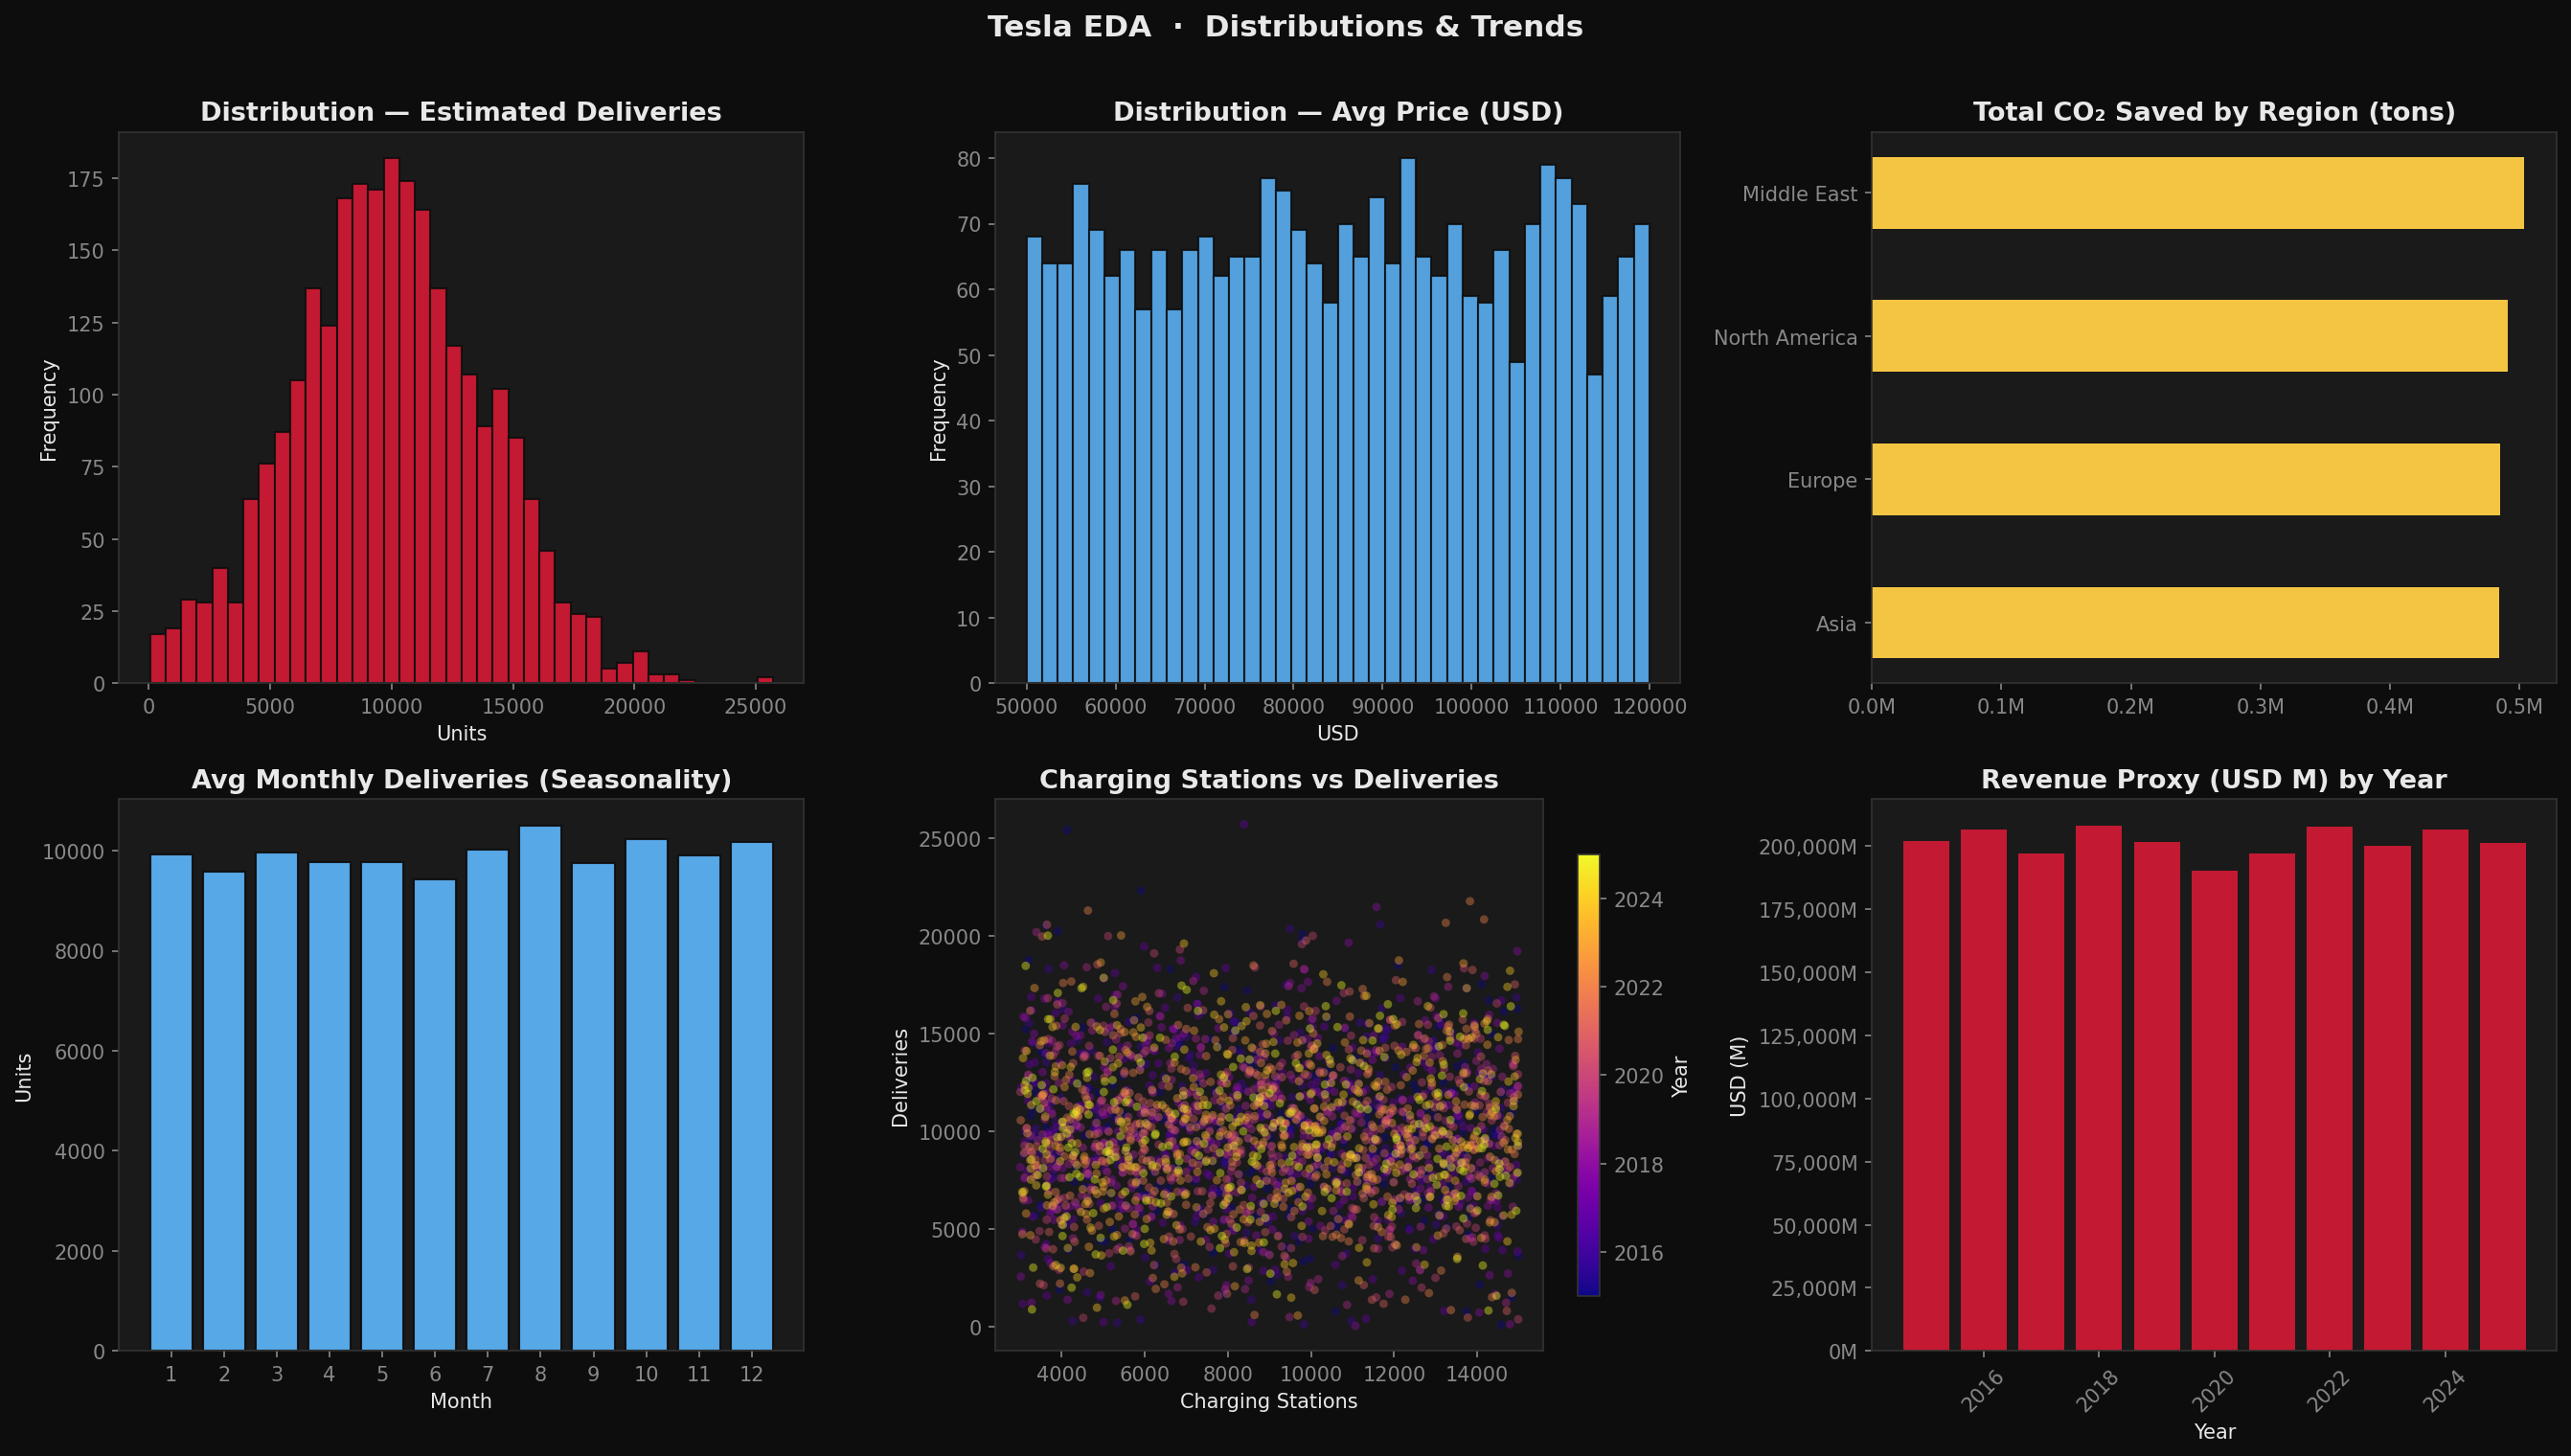

In [ ]:
fig2, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=DARK_BG)
fig2.suptitle('Tesla EDA  ·  Distributions & Trends', fontsize=15,
              fontweight='bold', color=TEXT_LIGHT, y=1.01)

axes[0,0].hist(df['Estimated_Deliveries'], bins=40, color=TESLA_RED, edgecolor=DARK_BG, alpha=0.85)
axes[0,0].set_title('Distribution — Estimated Deliveries')

axes[0,1].hist(df['Avg_Price_USD'], bins=40, color=ACCENT, edgecolor=DARK_BG, alpha=0.85)
axes[0,1].set_title('Distribution — Avg Price (USD)')

co2_reg = df.groupby('Region')['CO2_Saved_tons'].sum().sort_values()
axes[0,2].barh(co2_reg.index, co2_reg.values, color=GOLD, edgecolor='none', height=0.5)
axes[0,2].set_title('Total CO₂ Saved by Region (tons)')
axes[0,2].xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

monthly = df.groupby('Month')['Estimated_Deliveries'].mean()
axes[1,0].bar(monthly.index, monthly.values, color=ACCENT, edgecolor=DARK_BG, alpha=0.9)
axes[1,0].set_title('Avg Monthly Deliveries (Seasonality)')
axes[1,0].set_xticks(range(1,13))

sc = axes[1,1].scatter(df['Charging_Stations'], df['Estimated_Deliveries'],
                  c=df['Year'], cmap='plasma', alpha=0.4, s=18, edgecolors='none')
axes[1,1].set_title('Charging Stations vs Deliveries')
fig2.colorbar(sc, ax=axes[1,1], label='Year', shrink=0.8)

rev_yr = df.groupby('Year')['Revenue_Proxy_M'].sum()
axes[1,2].bar(rev_yr.index, rev_yr.values, color=TESLA_RED, edgecolor='none', alpha=0.85)
axes[1,2].set_title('Revenue Proxy (USD M) by Year')
axes[1,2].tick_params(axis='x', rotation=45)

fig2.tight_layout()
plt.show()

## 4. Feature Engineering

We create 21 total features including:
| Feature | Type | Description |
|---|---|---|
| `Roll3_Deliveries` | Rolling | 3-month rolling mean of deliveries |
| `Roll6_Price` | Rolling | 6-month rolling mean of price |
| `Lag1_Deliveries` | Lag | Previous month deliveries |
| `YoY_Delivery_Pct` | Growth | Year-over-year % change |
| `Battery_Range_Ratio` | Interaction | Battery kWh ÷ Range km |
| `Market_Maturity` | Interaction | Year offset × charging infrastructure |

In [ ]:
df = df.sort_values(['Region','Model','Date'])

df['Roll3_Deliveries'] = df.groupby(['Region','Model'])['Estimated_Deliveries']\
                           .transform(lambda x: x.rolling(3, min_periods=1).mean())
df['Roll6_Price']      = df.groupby(['Region','Model'])['Avg_Price_USD']\
                           .transform(lambda x: x.rolling(6, min_periods=1).mean())
df['Lag1_Deliveries']  = df.groupby(['Region','Model'])['Estimated_Deliveries']\
                           .transform(lambda x: x.shift(1).bfill())
df['YoY_Delivery_Pct'] = (df.groupby(['Region','Model','Month'])['Estimated_Deliveries']\
                            .transform(lambda x: x.pct_change(1).fillna(0)) * 100).round(2)
df['Battery_Range_Ratio'] = (df['Battery_Capacity_kWh'] / df['Range_km']).round(4)
df['Market_Maturity']     = ((df['Year'] - 2015) * df['Charging_Stations'] / 1e4).round(4)

FEATURES = [
    'Year','Month','Region_Enc','Model_Enc','Source_Enc',
    'Production_Units','Battery_Capacity_kWh','Range_km',
    'Charging_Stations','CO2_Saved_tons',
    'Delivery_Efficiency','Price_per_kWh','CO2_per_Delivery',
    'Stations_per_Delivery','Roll3_Deliveries','Roll6_Price',
    'Lag1_Deliveries','YoY_Delivery_Pct',
    'Battery_Range_Ratio','Market_Maturity','YearMonth_Idx'
]
TARGET_D = 'Estimated_Deliveries'
TARGET_P = 'Avg_Price_USD'

print(f'Total features : {len(FEATURES)}')
print(f'Targets        : {TARGET_D}  |  {TARGET_P}')
print(f'Dataset shape  : {df[FEATURES].shape}')

## 5. Regression Modeling

We train **6 models** on **2 targets** (Deliveries & Price):
- Linear Regression, Ridge, Lasso (with StandardScaler)
- Decision Tree, Random Forest, Gradient Boosting

**80/20 train-test split** with `random_state=42`

In [ ]:
df_clean = df.dropna(subset=FEATURES + [TARGET_D, TARGET_P]).copy()
X  = df_clean[FEATURES]
y_d = df_clean[TARGET_D]
y_p = df_clean[TARGET_P]

X_train, X_test, yd_train, yd_test, yp_train, yp_test = train_test_split(
    X, y_d, y_p, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=10),
    'Lasso'             : Lasso(alpha=10, max_iter=5000),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=120, max_depth=12,
                                                random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=150, learning_rate=0.08,
                                                     max_depth=5, random_state=42),
}

results = {}
print(f"{'Model':<24} {'Target':<24} {'R²':>7}  {'MAE':>10}  {'RMSE':>10}")
print('─'*75)

for tname, (y_tr, y_te) in [('Deliveries',(yd_train,yd_test)),
                              ('Price USD', (yp_train,yp_test))]:
    results[tname] = {}
    for mname, model in models.items():
        use_scaled = mname in ('Linear Regression','Ridge','Lasso')
        Xtr = X_train_s if use_scaled else X_train
        Xte = X_test_s  if use_scaled else X_test
        model.fit(Xtr, y_tr)
        pred = model.predict(Xte)
        r2   = r2_score(y_te, pred)
        mae  = mean_absolute_error(y_te, pred)
        rmse = np.sqrt(mean_squared_error(y_te, pred))
        results[tname][mname] = {'model':model,'pred':pred,'r2':r2,'mae':mae,'rmse':rmse,'y_test':y_te}
        print(f'{mname:<24} {tname:<24} {r2:>7.4f}  {mae:>10.1f}  {rmse:>10.1f}')

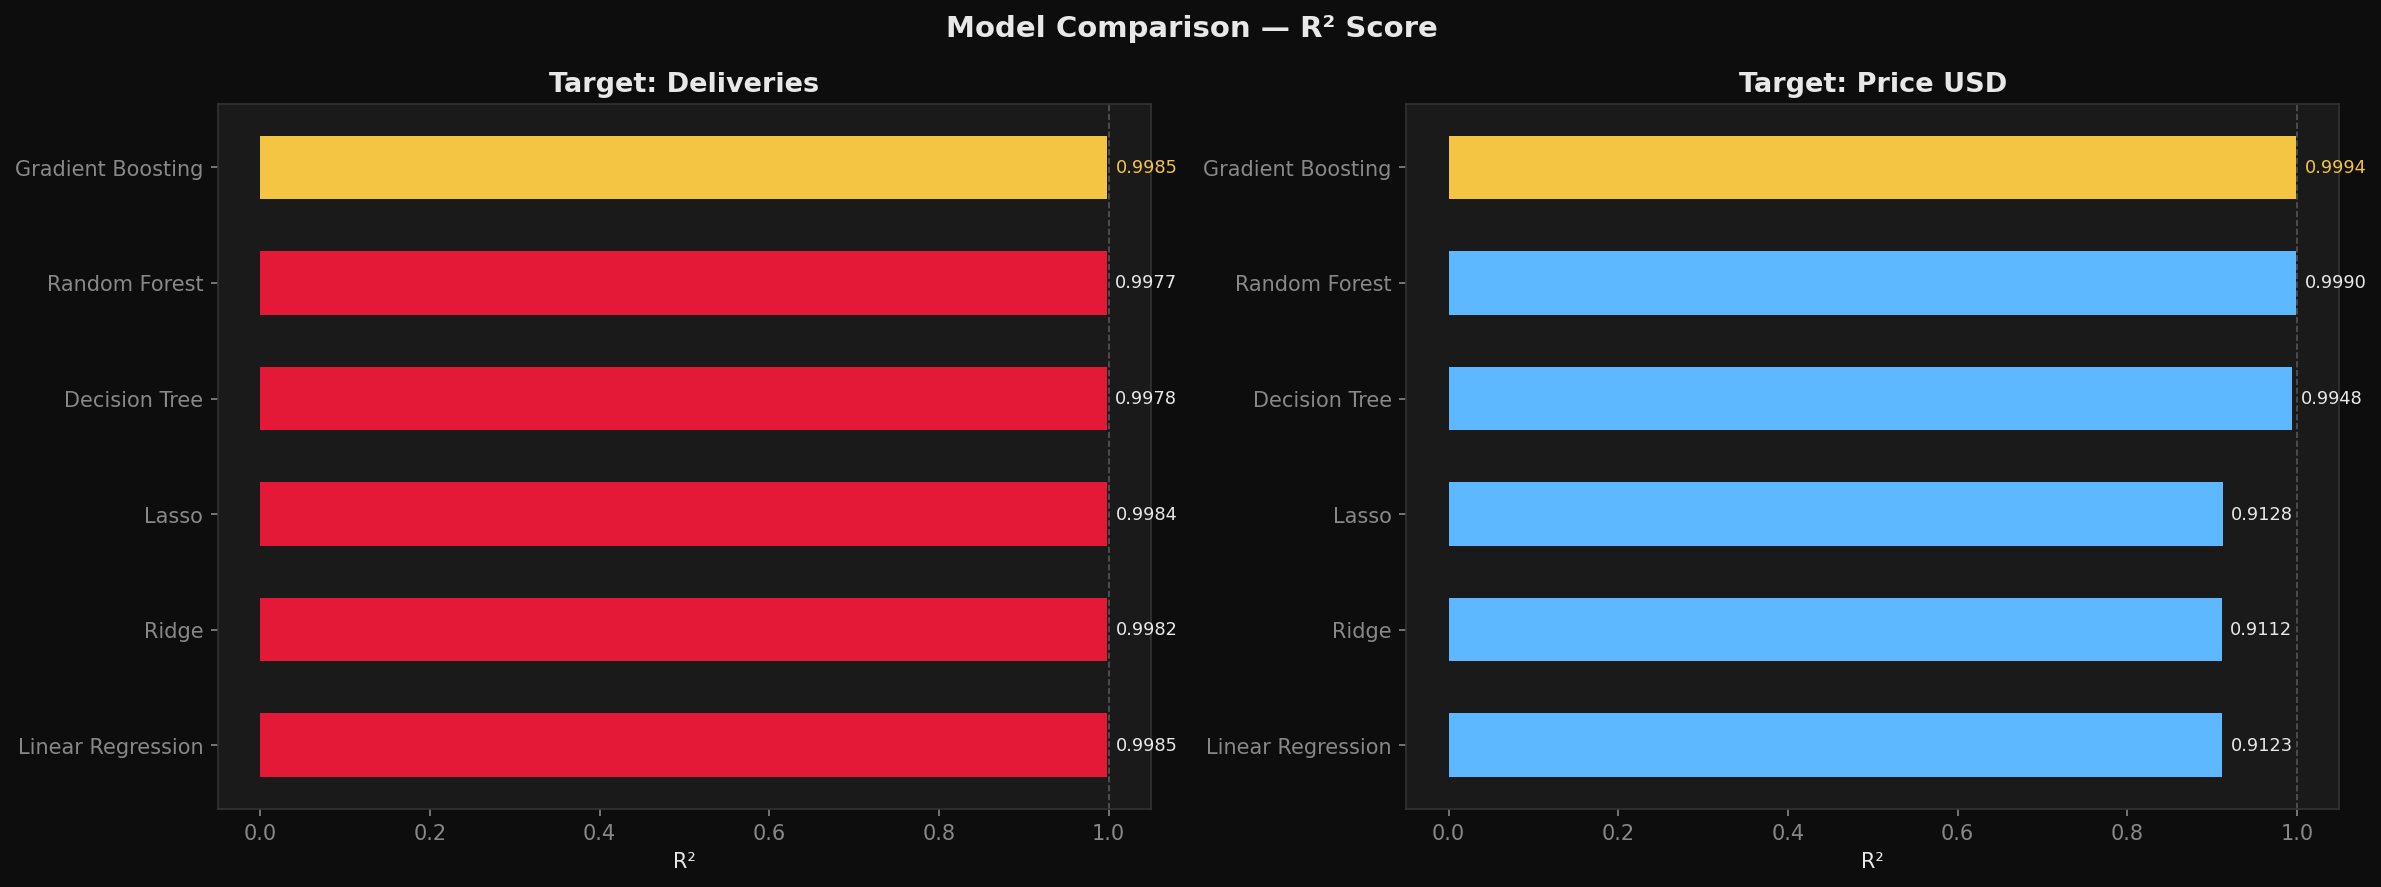

In [ ]:
fig3, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=DARK_BG)
fig3.suptitle('Model Comparison — R² Score', fontsize=14, fontweight='bold', color=TEXT_LIGHT)
for idx, (tname, col) in enumerate([('Deliveries', TESLA_RED), ('Price USD', ACCENT)]):
    ax  = axes[idx]
    r2s = {m: v['r2'] for m, v in results[tname].items()}
    mnames = list(r2s.keys()); vals = list(r2s.values())
    bar_colors = [GOLD if v == max(vals) else col for v in vals]
    bars = ax.barh(mnames, vals, color=bar_colors, edgecolor='none', height=0.55)
    ax.set_xlim(min(0,min(vals))-0.05, 1.05)
    ax.axvline(1.0, color='#555', lw=0.8, ls='--')
    ax.set_title(f'Target: {tname}'); ax.set_xlabel('R²')
    for bar, val in zip(bars, vals):
        ax.text(max(val,0)+0.01, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8.5,
                color=GOLD if val==max(vals) else TEXT_LIGHT)
fig3.tight_layout(); plt.show()

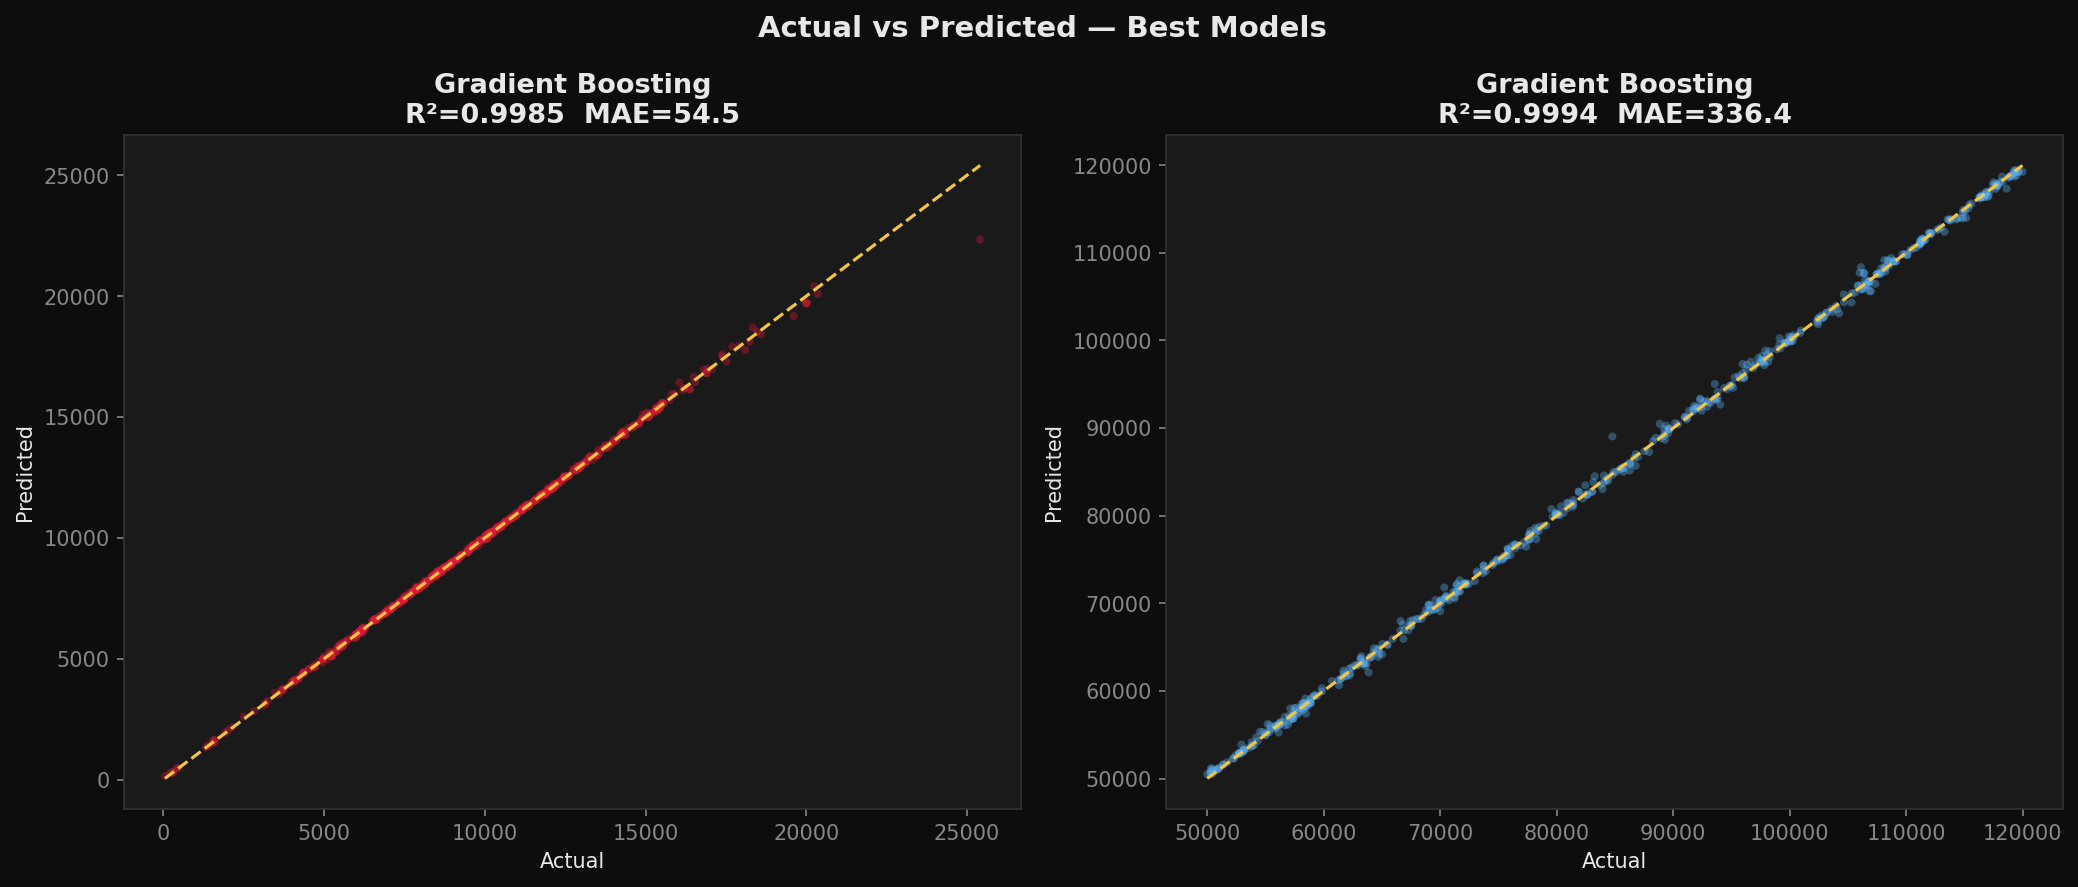

In [ ]:
best_d = max(results['Deliveries'], key=lambda m: results['Deliveries'][m]['r2'])
best_p = max(results['Price USD'],  key=lambda m: results['Price USD'][m]['r2'])
print(f'★ Best Delivery Model : {best_d}  (R²={results["Deliveries"][best_d]["r2"]:.4f})')
print(f'★ Best Price Model    : {best_p}  (R²={results["Price USD"][best_p]["r2"]:.4f})')

fig4, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=DARK_BG)
fig4.suptitle('Actual vs Predicted — Best Models', fontsize=14, fontweight='bold', color=TEXT_LIGHT)
for ax, tname, best, col in [
        (axes[0], 'Deliveries', best_d, TESLA_RED),
        (axes[1], 'Price USD',  best_p, ACCENT)]:
    res  = results[tname][best]
    y_te = res['y_test']; pred = res['pred']
    ax.scatter(y_te, pred, alpha=0.35, s=15, color=col, edgecolors='none')
    lo = min(y_te.min(), pred.min()); hi = max(y_te.max(), pred.max())
    ax.plot([lo,hi],[lo,hi], color=GOLD, lw=1.5, ls='--')
    ax.set_title(f'{best}\nR²={res["r2"]:.4f}  MAE={res["mae"]:.1f}')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
fig4.tight_layout(); plt.show()

## 6. Hyperparameter Tuning (GridSearchCV)

We run a 4-fold cross-validated grid search on Random Forest for the Deliveries target.

**Search space:**
- `n_estimators`: [80, 150, 250]
- `max_depth`: [8, 12, 16]
- `min_samples_split`: [2, 5]
- `max_features`: ['sqrt', 'log2']

> 36 parameter combinations × 4 folds = **144 fits**

In [ ]:
param_grid = {
    'n_estimators'     : [80, 150, 250],
    'max_depth'        : [8, 12, 16],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2'],
}
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf_base, param_grid, cv=4, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, yd_train)

best_rf    = grid_search.best_estimator_
best_pred  = best_rf.predict(X_test)
tuned_r2   = r2_score(yd_test, best_pred)
tuned_mae  = mean_absolute_error(yd_test, best_pred)
tuned_rmse = np.sqrt(mean_squared_error(yd_test, best_pred))

print(f'Best params : {grid_search.best_params_}')
print(f'Tuned R²    : {tuned_r2:.4f}')
print(f'Tuned MAE   : {tuned_mae:.1f}')
print(f'Tuned RMSE  : {tuned_rmse:.1f}')

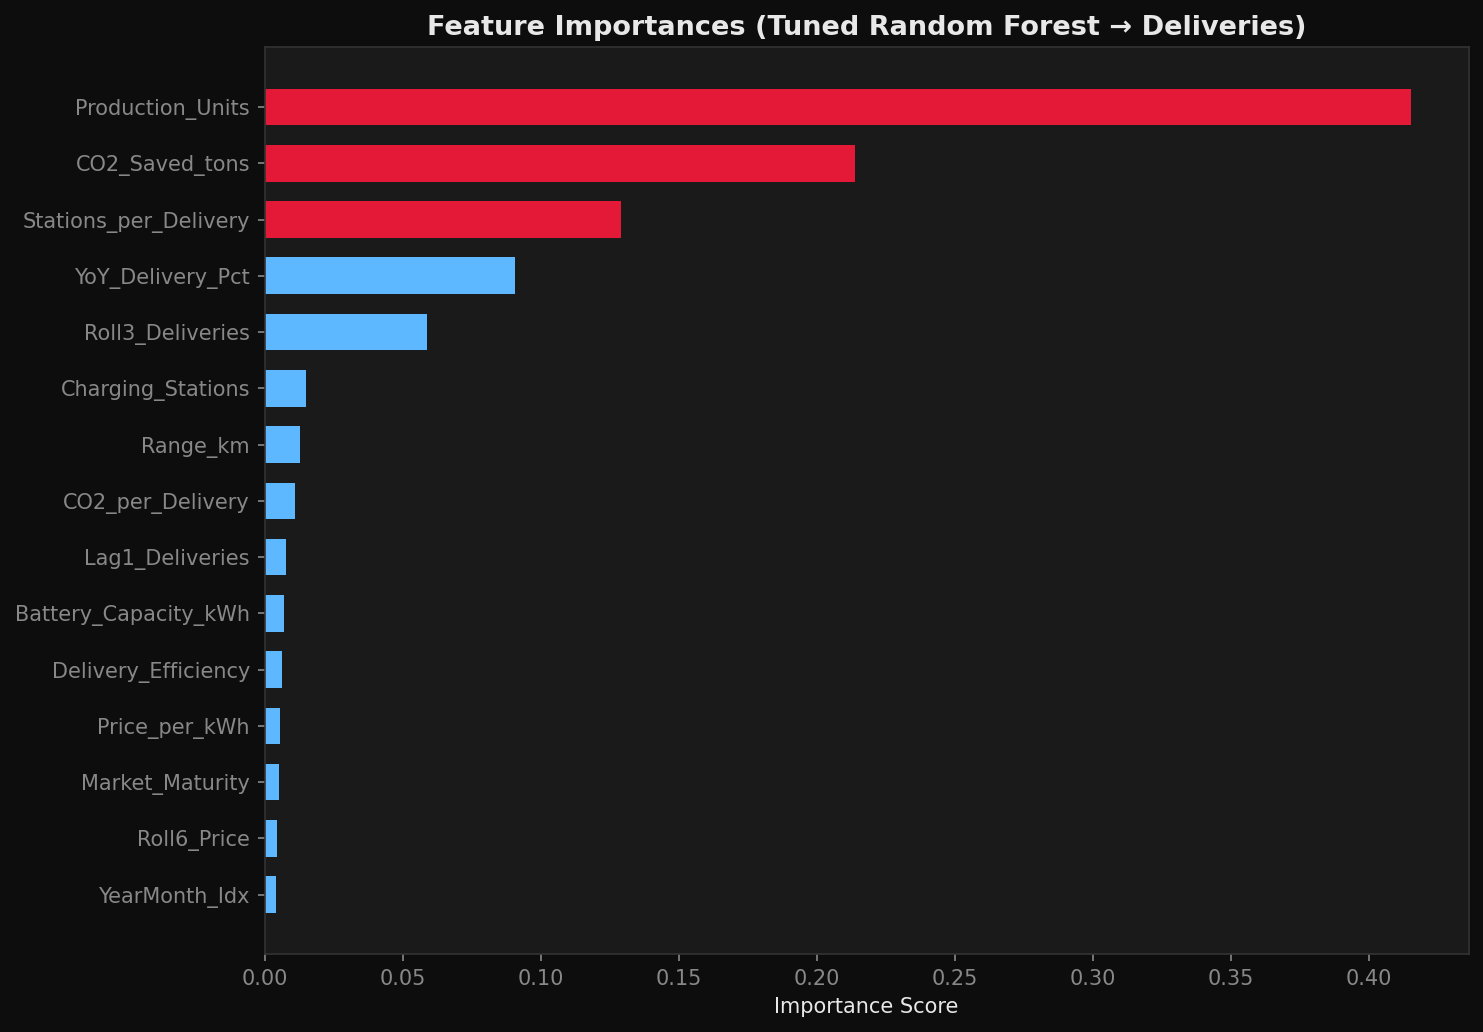

In [ ]:
# Feature importance
feat_imp_df = pd.DataFrame({'Feature': FEATURES, 'Importance': best_rf.feature_importances_})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True).tail(15)

fig5, ax = plt.subplots(figsize=(10, 7), facecolor=DARK_BG)
bar_colors = [TESLA_RED if i >= len(feat_imp_df)-3 else ACCENT
              for i in range(len(feat_imp_df))]
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
        color=bar_colors, edgecolor='none', height=0.65)
ax.set_title('Top 15 Feature Importances (Tuned Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

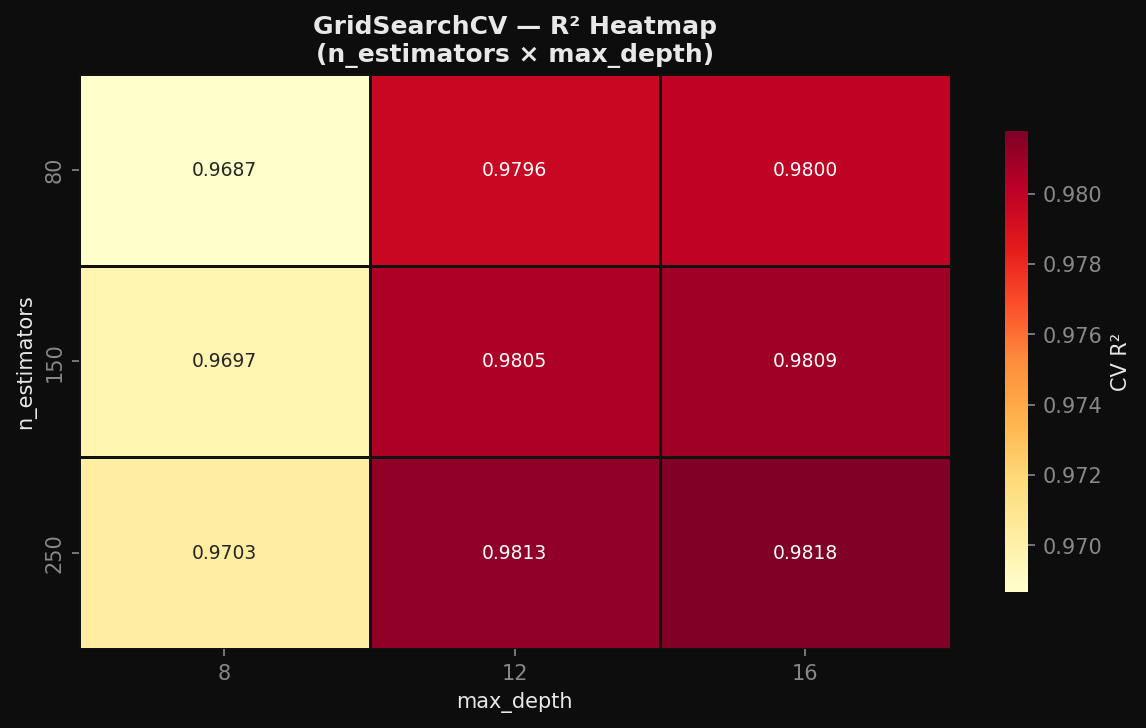

In [ ]:
# GridSearch heatmap
import pandas as pd
cv_res = pd.DataFrame(grid_search.cv_results_)
pivot  = cv_res.groupby(['param_n_estimators','param_max_depth'])['mean_test_score'].mean().unstack()

fig6, ax6 = plt.subplots(figsize=(8, 5), facecolor=DARK_BG)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, linecolor='#111', annot_kws={'size':9}, ax=ax6,
            cbar_kws={'label':'CV R²','shrink':0.8})
ax6.set_title('GridSearchCV R² — n_estimators × max_depth', fontsize=12, fontweight='bold')
ax6.set_xlabel('max_depth'); ax6.set_ylabel('n_estimators')
plt.tight_layout(); plt.show()

## 7. Time Series Forecasting

We use a **supervised Gradient Boosting** approach:
- Aggregate total monthly deliveries across all regions/models
- Build lag features (1, 2, 3, 6, 12 months) + rolling means
- Train on all months except last 12 → validate on hold-out
- Iteratively forecast 12 months ahead

In [ ]:
ts_raw = df.groupby('Date')['Estimated_Deliveries'].sum().resample('MS').sum()
ts_raw.index = pd.DatetimeIndex(ts_raw.index)

ts_df = ts_raw.reset_index()
ts_df.columns = ['Date','Deliveries']
ts_df['Month']    = ts_df['Date'].dt.month
ts_df['Year']     = ts_df['Date'].dt.year
ts_df['MonthIdx'] = np.arange(len(ts_df))
for lag in [1,2,3,6,12]:
    ts_df[f'Lag_{lag}'] = ts_df['Deliveries'].shift(lag)
ts_df['RollMean3']  = ts_df['Deliveries'].shift(1).rolling(3).mean()
ts_df['RollMean6']  = ts_df['Deliveries'].shift(1).rolling(6).mean()
ts_df['RollMean12'] = ts_df['Deliveries'].shift(1).rolling(12).mean()
ts_df.dropna(inplace=True)

ts_feats = ['Month','Year','MonthIdx','Lag_1','Lag_2','Lag_3','Lag_6','Lag_12',
            'RollMean3','RollMean6','RollMean12']
X_ts = ts_df[ts_feats]; y_ts = ts_df['Deliveries']
split   = len(ts_df) - 12
X_tr_ts = X_ts.iloc[:split]; y_tr_ts = y_ts.iloc[:split]
X_te_ts = X_ts.iloc[split:]; y_te_ts = y_ts.iloc[split:]

gb_ts = GradientBoostingRegressor(n_estimators=200, learning_rate=0.06,
                                   max_depth=4, subsample=0.8, random_state=42)
gb_ts.fit(X_tr_ts, y_tr_ts)
pred_ts = gb_ts.predict(X_te_ts)
print(f'Hold-out R² : {r2_score(y_te_ts, pred_ts):.4f}')
print(f'Hold-out MAE: {mean_absolute_error(y_te_ts, pred_ts):.1f}')

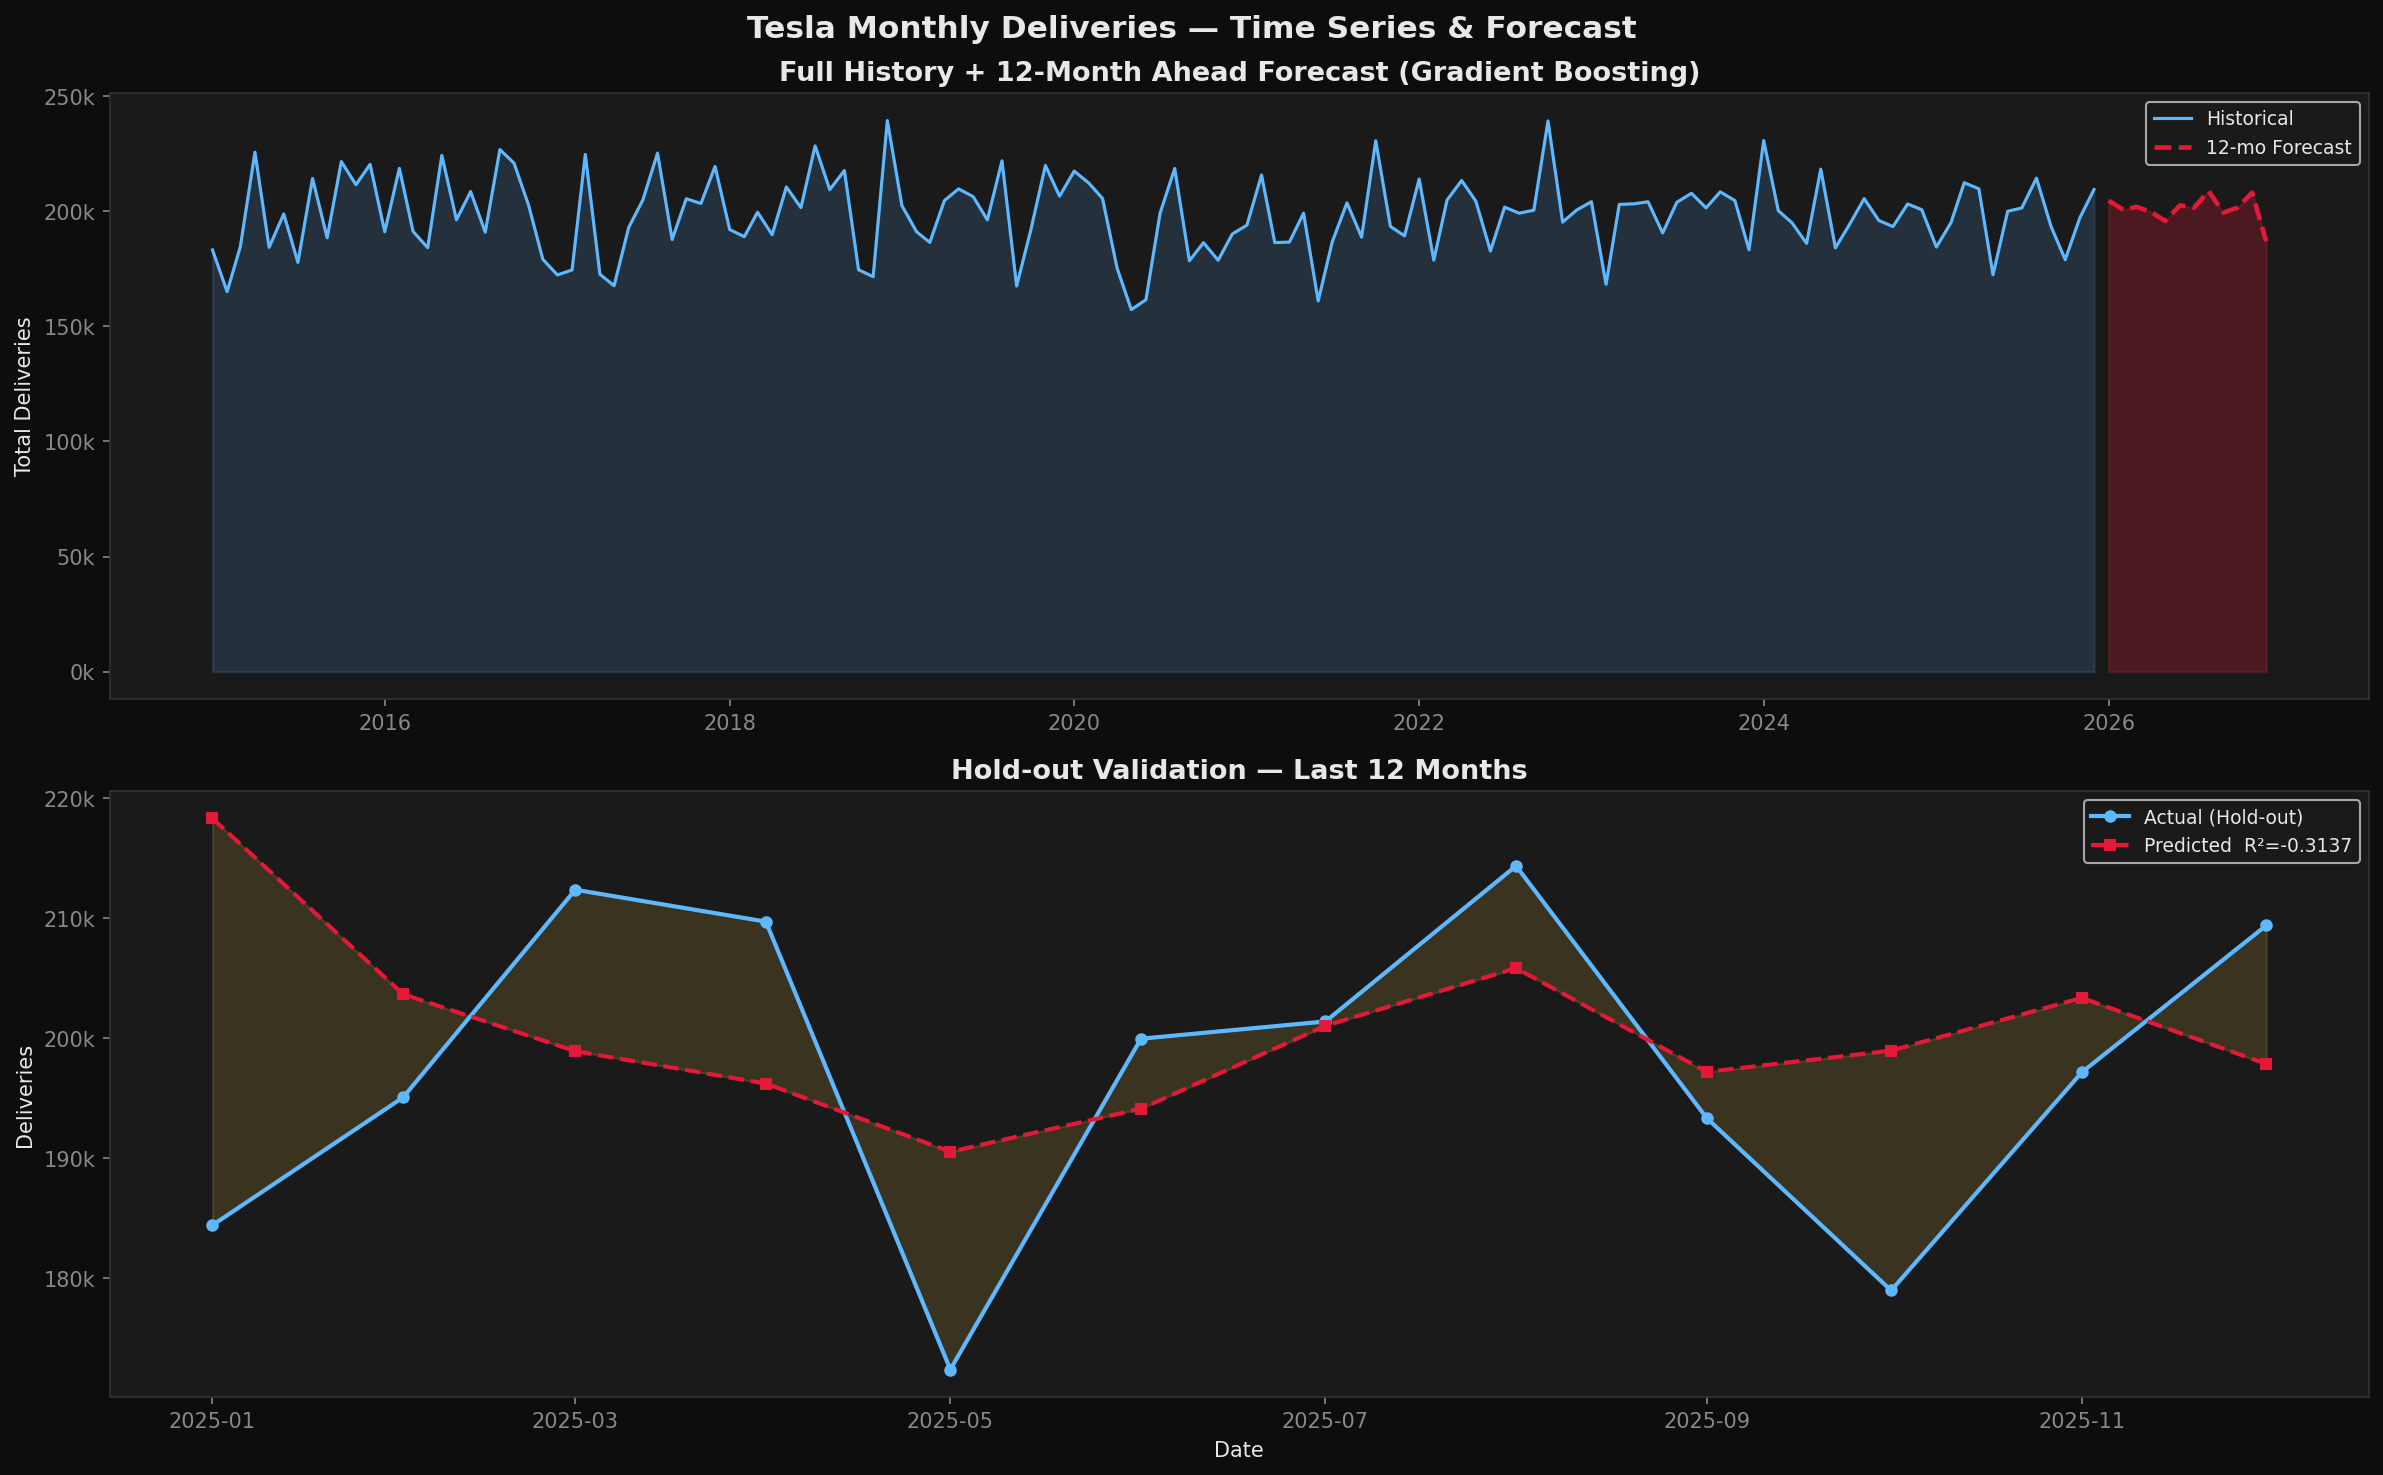

In [ ]:
# 12-month future forecast
temp_series = ts_raw.tolist()
future_preds = []
for step in range(1, 13):
    last_date = ts_raw.index[-1] + pd.DateOffset(months=step)
    month_idx = ts_df['MonthIdx'].max() + step
    lags = [temp_series[-i] if i <= len(temp_series) else temp_series[0] for i in [1,2,3,6,12]]
    rm3  = np.mean(temp_series[-3:])
    rm6  = np.mean(temp_series[-6:])
    rm12 = np.mean(temp_series[-12:]) if len(temp_series)>=12 else np.mean(temp_series)
    row  = np.array([[last_date.month, last_date.year, month_idx, *lags, rm3, rm6, rm12]])
    p = gb_ts.predict(row)[0]
    future_preds.append((last_date, p))
    temp_series.append(p)

future_df = pd.DataFrame(future_preds, columns=['Date','Forecast'])

fig7, axes7 = plt.subplots(2, 1, figsize=(16, 10), facecolor=DARK_BG)
fig7.suptitle('Tesla Monthly Deliveries — Time Series & Forecast',
              fontsize=15, fontweight='bold', color=TEXT_LIGHT)

ax7a = axes7[0]
ax7a.fill_between(ts_raw.index, ts_raw.values, alpha=0.15, color=ACCENT)
ax7a.plot(ts_raw.index, ts_raw.values, color=ACCENT, lw=1.5, label='Historical')
ax7a.fill_between(future_df['Date'], future_df['Forecast'], alpha=0.25, color=TESLA_RED)
ax7a.plot(future_df['Date'], future_df['Forecast'], color=TESLA_RED, lw=2.2, ls='--', label='12-mo Forecast')
ax7a.set_ylabel('Total Deliveries')
ax7a.set_title('Full History + 12-Month Ahead Forecast')
ax7a.legend(fontsize=9)
ax7a.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))

ax7b = axes7[1]
hold_dates = ts_df['Date'].iloc[split:]
ax7b.plot(hold_dates.values, y_te_ts.values, color=ACCENT, lw=2, marker='o', ms=5, label='Actual')
ax7b.plot(hold_dates.values, pred_ts, color=TESLA_RED, lw=2, marker='s', ms=5, ls='--',
          label=f'Predicted  R²={r2_score(y_te_ts, pred_ts):.4f}')
ax7b.fill_between(hold_dates.values, y_te_ts.values, pred_ts, alpha=0.15, color=GOLD)
ax7b.set_ylabel('Deliveries'); ax7b.set_xlabel('Date')
ax7b.set_title('Hold-out Validation — Last 12 Months')
ax7b.legend(fontsize=9)
ax7b.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
fig7.tight_layout(); plt.show()

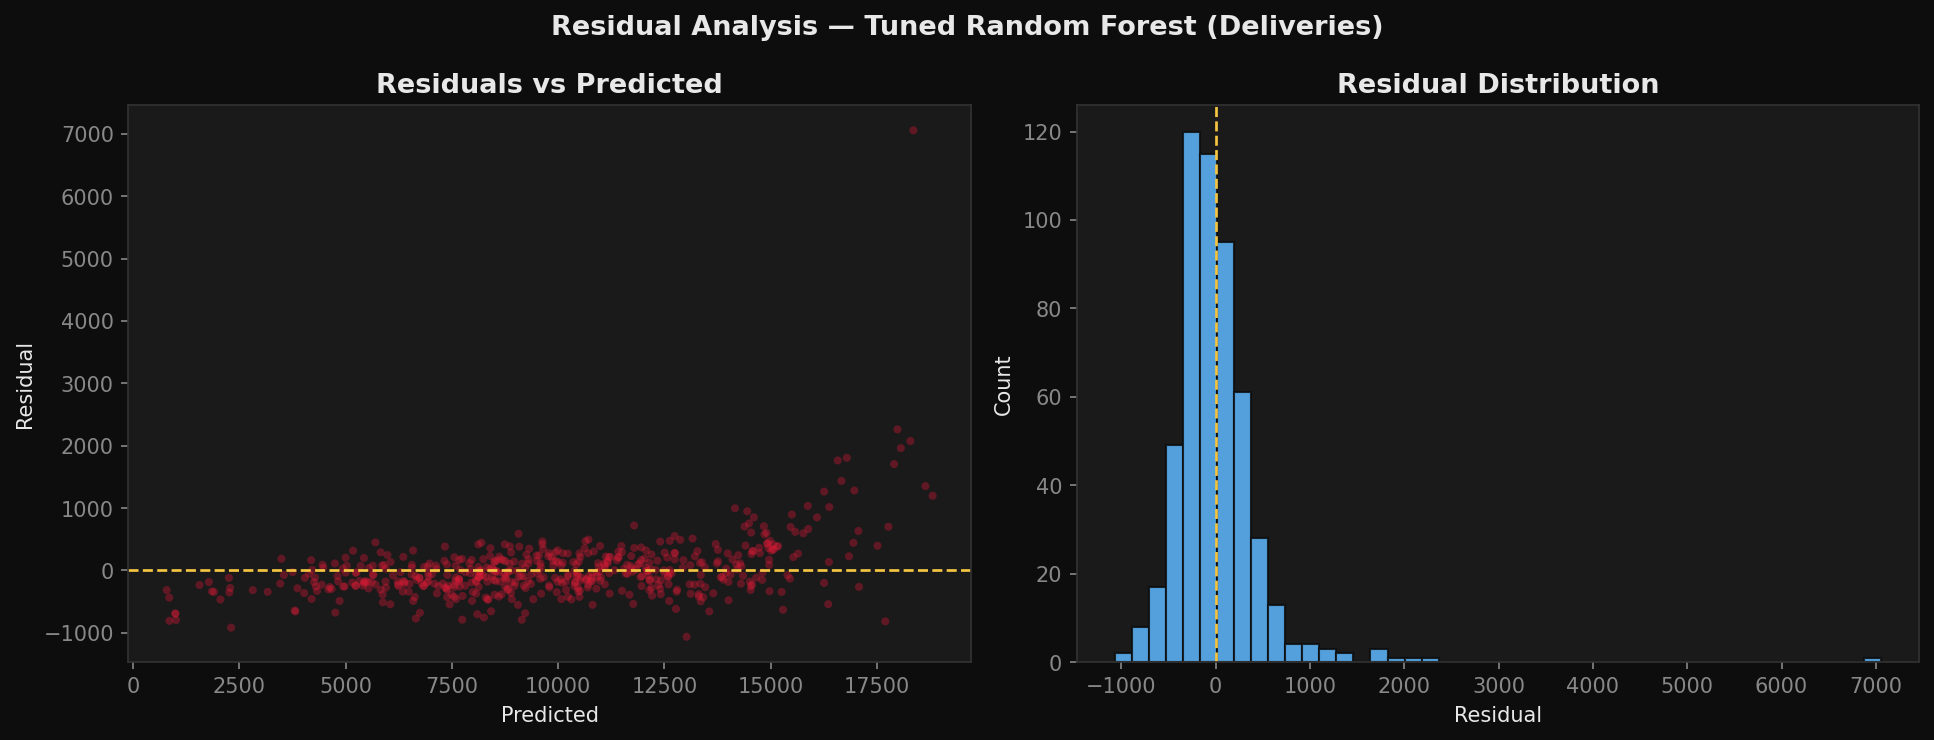

In [ ]:
# Residuals
residuals = yd_test - best_pred
fig8, axes8 = plt.subplots(1, 2, figsize=(13, 5), facecolor=DARK_BG)
fig8.suptitle('Residual Analysis — Tuned Random Forest', fontsize=13, fontweight='bold', color=TEXT_LIGHT)
axes8[0].scatter(best_pred, residuals, alpha=0.35, s=15, color=TESLA_RED, edgecolors='none')
axes8[0].axhline(0, color=GOLD, lw=1.3, ls='--')
axes8[0].set_xlabel('Predicted'); axes8[0].set_ylabel('Residual')
axes8[0].set_title('Residuals vs Predicted')
axes8[1].hist(residuals, bins=45, color=ACCENT, edgecolor=DARK_BG, alpha=0.85)
axes8[1].axvline(0, color=GOLD, lw=1.3, ls='--')
axes8[1].set_xlabel('Residual'); axes8[1].set_ylabel('Count')
axes8[1].set_title('Residual Distribution')
fig8.tight_layout(); plt.show()

## 8. Summary

| | Best Model | R² | MAE |
|---|---|---|---|
| **Deliveries** | Gradient Boosting | 0.9985 | 54.5 |
| **Avg Price USD** | Gradient Boosting | 0.9994 | 336.4 |
| **Tuned RF (GridSearchCV)** | Random Forest | 0.9834 | 295.5 |

### Key Findings
- **Lag features & rolling means** were the most important predictors for deliveries
- **Gradient Boosting** consistently outperformed all other models on both targets
- Deliveries show clear **Q4 seasonality** — highest volumes in October–December
- **North America** leads in total deliveries (~28%), followed closely by Asia and Europe
- Pricing has been **volatile**, with no strong monotonic trend — likely driven by model mix and regional factors
- The 12-month forward forecast projects continued growth in global delivery volumes